# 03 — Analysis

Consolidated confirmed-frame analysis for the paper.  
**Prerequisite:** run `01_pipeline.ipynb` then `02_ml_framing.ipynb` first.

Primary data source: `data/processed/ml_frame_confirmed.parquet`  
(keyword ∩ embedding > 0 — true binary article-level frame flags, values ∈ {0, 1})

Daily timestamps are recovered by joining with `data/interim/gdelt_preprocessed.parquet`
on `DocumentIdentifier` (100% match rate). Frame prevalence, volume, and per-region series
are all smoothed with a 14-day centred rolling mean before plotting.

Produces:
- §4.1 coverage overview numbers
- **Table 2** (`tab:frame_stats`): confirmed frame prevalence per frame
- **Table 3** (`tab:eventstudy`): event-study Δ (all 6 frames) per milestone
- Regional breakdown table cited in §4.3
- `paper/figures/fig_1_volume_frames.{pdf,png}` — single-panel stacked area (confirmed frame prevalence by frame, 14-day avg) + articles/day line on right axis
- `paper/figures/fig_2_regional_framing.{pdf,png}` — US/EU/UK daily confirmed frame prevalence for top 3 frames (14-day avg), 3 compact panels
- `data/processed/event_studies_confirmed.parquet`

In [1]:
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

ROOT      = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed"
INTERIM   = ROOT / "data" / "interim"
FIGURES   = ROOT / "paper" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))
from src.dictionaries import FRAME_COLS, MILESTONES
from src.analysis import (
    event_study, frame_coverage_rate, frame_shares,
    region_comparison, region_frame_shares_over_time,
)

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.4,
})

FRAME_NAMES = [c.replace("frame_", "") for c in FRAME_COLS]

FRAME_LABELS = {
    "regulation_governance":       "Regulation & Governance",
    "risk_safety":                 "Risk & Safety",
    "innovation_opportunity":      "Innovation & Opportunity",
    "economic_competition_labour": "Econ. Comp. & Labour",
    "rights_privacy":              "Rights & Privacy",
    "misinformation_integrity":    "Misinfo. & Integrity",
}

FRAME_COLORS = {
    "regulation_governance":       "#2166ac",
    "risk_safety":                 "#d6604d",
    "innovation_opportunity":      "#4dac26",
    "economic_competition_labour": "#f4a582",
    "rights_privacy":              "#762a83",
    "misinformation_integrity":    "#92c5de",
}

REGION_COLORS = {"US": "#1f78b4", "EU": "#e31a1c", "UK": "#33a02c"}

MILESTONE_SHORT = {
    "chatgpt_launch":      "ChatGPT",
    "pause_ai_letter":     "Pause AI",
    "bletchley_summit":    "Bletchley",
    "eu_ai_act_agreement": "EU Act\nagree.",
    "seoul_summit":        "Seoul",
    "eu_ai_act_in_force":  "EU Act\nin force",
    "openai_o1":           "OpenAI o1",
    "deepseek_trump":      "DeepSeek\n+Trump EO",
    "eu_ai_prohibited":    "EU AI\nbans",
    "gpai_obligations":    "GPAI\noblig.",
    "claude_fable_us_ban": "Fable 5\n+US ban",
}

MILESTONE_PRETTY = {
    "chatgpt_launch":      "ChatGPT launch (Nov 2022)",
    "pause_ai_letter":     "Pause AI letter (Mar 2023)",
    "bletchley_summit":    "Bletchley Summit (Nov 2023)",
    "eu_ai_act_agreement": "EU AI Act agreement (Dec 2023)",
    "seoul_summit":        "Seoul Summit (May 2024)",
    "eu_ai_act_in_force":  "EU AI Act in force (Aug 2024)",
    "openai_o1":           "OpenAI o1 release (Sep 2024)",
    "deepseek_trump":      "DeepSeek R1 + Trump AI EO (Jan 2025)",
    "eu_ai_prohibited":    "EU AI prohibited practices (Feb 2025)",
    "gpai_obligations":    "GPAI obligations (Aug 2025)",
    "claude_fable_us_ban": "Claude Fable 5 + US ban (Jun 2026)",
}

# Per-milestone label y (axes fraction). Default 0.96; close pairs are staggered.
MILESTONE_YLABEL = {
    "eu_ai_prohibited": 0.78,   # 13 days after deepseek_trump — drop label to avoid overlap
}

# Savitzky-Golay second-pass constants (applied after 14-day rolling mean)
SG_WINDOW = 7   # odd number; ~3-day polynomial smoothing pass
SG_POLY   = 2   # quadratic — preserves peak shape better than a second rolling mean

def _sg(series: pd.Series) -> pd.Series:
    """Apply Savitzky-Golay filter to a Series, filling edge NaNs with 0 first."""
    filled = series.fillna(0).values
    return pd.Series(savgol_filter(filled, SG_WINDOW, SG_POLY), index=series.index)

def _save(fig, name):
    fig.savefig(FIGURES / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    print(f"Saved {name}.pdf / .png")

In [2]:
# Confirmed frames — primary analysis data
# Columns: DocumentIdentifier, month (Period[M]), region,
#          dominant_frame_confirmed, frame_* (binary 0/1)
cf = pd.read_parquet(PROCESSED / "ml_frame_confirmed.parquet")

# Monthly article counts (from 01_pipeline)
monthly_vol = pd.read_parquet(PROCESSED / "monthly_volume.parquet")

# Governance vs. total GenAI articles per month
cov = pd.read_parquet(PROCESSED / "coverage_validation.parquet")

# Tone per keyword-dominant frame (indicative only)
tone_frame = pd.read_parquet(PROCESSED / "tone_by_frame.parquet")

print(f"Confirmed frames: {len(cf):,} articles, {cf['month'].nunique()} months")
print(f"Month range:      {cf['month'].min()} → {cf['month'].max()}")
print(f"Frame columns:    {FRAME_COLS}")

Confirmed frames: 1,116,091 articles, 44 months
Month range:      2022-11 → 2026-06
Frame columns:    ['frame_innovation_opportunity', 'frame_risk_safety', 'frame_regulation_governance', 'frame_rights_privacy', 'frame_economic_competition_labour', 'frame_misinformation_integrity']


In [3]:
# Join confirmed-frame articles with daily timestamps from the interim file.
# Loaded early so cf_daily is available for both the event study and the figures.
interim_dates = pd.read_parquet(
    INTERIM / "gdelt_preprocessed.parquet",
    columns=["DocumentIdentifier", "DATE"],
)
cf_daily = cf.merge(interim_dates, on="DocumentIdentifier", how="left")
cf_daily["date"] = pd.to_datetime(cf_daily["DATE"]).dt.normalize()

matched = cf_daily["date"].notna().mean()
print(f"Date merge coverage: {matched:.1%} of articles have a daily timestamp")

# Daily volume and confirmed frame prevalence
daily_vol    = cf_daily.groupby("date").size().rename("count")
daily_hits   = cf_daily.groupby("date")[FRAME_COLS].sum()
daily_counts = cf_daily.groupby("date").size()
daily_prev   = daily_hits.div(daily_counts, axis=0).fillna(0)
daily_prev.columns = FRAME_NAMES

# 14-day centred rolling mean, then Savitzky-Golay second pass (window=7, poly=2)
ROLL = 14
vol_smooth  = _sg(daily_vol.rolling(ROLL, min_periods=7, center=True).mean())
prev_smooth = daily_prev.rolling(ROLL, min_periods=7, center=True).mean().apply(_sg)

print(f"Date range:    {daily_vol.index.min().date()} → {daily_vol.index.max().date()}")
print(f"Days covered:  {len(daily_vol)}")
print(f"Daily volume — min: {daily_vol.min()}, max: {daily_vol.max()}, mean: {daily_vol.mean():.0f}")

# Per-region daily prevalence — used by Figure 2
REGIONS = ["US", "EU", "UK"]
daily_region_hits   = cf_daily.groupby(["date", "region"])[FRAME_COLS].sum()
daily_region_counts = cf_daily.groupby(["date", "region"]).size()
daily_region_prev   = daily_region_hits.div(daily_region_counts, axis=0).fillna(0)
daily_region_prev.columns = FRAME_NAMES

region_smooth = {}
for region in REGIONS:
    r_df = daily_region_prev.xs(region, level="region").reindex(daily_vol.index)
    rolled = r_df.rolling(ROLL, min_periods=7, center=True).mean()
    region_smooth[region] = rolled.apply(_sg)

print(f"Regional daily series computed for: {list(region_smooth.keys())}")

Date merge coverage: 100.0% of articles have a daily timestamp
Date range:    2022-11-01 → 2026-06-17
Days covered:  1308
Daily volume — min: 160, max: 3188, mean: 853
Regional daily series computed for: ['US', 'EU', 'UK']


## §4.1 — Coverage Overview

Numbers cited verbatim in the paper.

In [4]:
total       = len(cf)
gov_rate    = cov["coverage_rate"].mean()
conf_stats  = frame_coverage_rate(cf)
conf_any    = conf_stats["any_frame_pct"]
n_confirmed = int(round(total * conf_any))

vol_early = monthly_vol["count"].iloc[:3]
vol_late  = monthly_vol["count"].iloc[-3:]

print("─" * 58)
print(f"  Total corpus articles:      {total:>12,}")
print(f"  Governance coverage rate:   {gov_rate:>11.1%}  of all GenAI articles")
print(f"  Confirmed ≥1 frame:         {conf_any:>11.1%}  ({n_confirmed:,} articles)")
print()
print(f"  Monthly volume — late 2022: {vol_early.min():,} – {vol_early.max():,} articles")
print(f"  Monthly volume — spr. 2026: {vol_late.min():,} – {vol_late.max():,} articles")
print(f"  Growth factor:              {vol_late.mean() / vol_early.mean():.2f}×")
print("─" * 58)

──────────────────────────────────────────────────────────
  Total corpus articles:         1,116,091
  Governance coverage rate:         50.7%  of all GenAI articles
  Confirmed ≥1 frame:               40.8%  (455,349 articles)

  Monthly volume — late 2022: 14,908 – 17,788 articles
  Monthly volume — spr. 2026: 20,680 – 28,582 articles
  Growth factor:              1.59×
──────────────────────────────────────────────────────────


## Monthly Confirmed Frame Prevalence

`frame_shares(cf)` sums binary frame flags per month and divides by monthly article count,
giving a true fraction in [0, 1].  
Values are bounded and directly interpretable: e.g. 0.165 = 16.5% of that month's articles
confirmed in the Regulation frame.

Used as input for Figure 1 (bottom panel) and Table 2.

In [5]:
# frame_shares strips the 'frame_' prefix → columns are bare frame names
monthly_prev = frame_shares(cf)

print(f"Shape:          {monthly_prev.shape}")
print(f"Max any value:  {monthly_prev.max().max():.4f}  (must be < 1.0)")
print(f"Any NaN:        {monthly_prev.isna().any().any()}")
print()
print(f"{'Frame':<38}  {'mean':>6}  {'max':>6}  {'peak month'}")
print("-" * 70)
for name in FRAME_NAMES:
    if name in monthly_prev.columns:
        col = monthly_prev[name]
        print(f"  {FRAME_LABELS[name]:<36}  {col.mean():.3f}  {col.max():.3f}  {col.idxmax()}")

Shape:          (44, 6)
Max any value:  0.2308  (must be < 1.0)
Any NaN:        False

Frame                                     mean     max  peak month
----------------------------------------------------------------------
  Innovation & Opportunity              0.096  0.131  2023-02
  Risk & Safety                         0.120  0.203  2025-03
  Regulation & Governance               0.165  0.231  2025-01
  Rights & Privacy                      0.036  0.065  2023-04
  Econ. Comp. & Labour                  0.077  0.109  2026-01
  Misinfo. & Integrity                  0.035  0.122  2024-06


## Table 2 — Confirmed Frame Prevalence

Reproduces `tab:frame_stats` in `paper/main.tex` (§4.2).

In [6]:
counts = (cf[FRAME_COLS] > 0).sum()
counts.index = FRAME_NAMES   # strip 'frame_' prefix

pct          = counts / total * 100
monthly_mean = monthly_prev[FRAME_NAMES].mean() * 100
tone_vals    = tone_frame.loc[FRAME_NAMES, "mean"]

table2 = pd.DataFrame({
    "Articles":       counts,
    "% Corpus":       pct.round(1),
    "Monthly (%)": monthly_mean.round(1),
    "Tone (mean)":    tone_vals.round(2),
}, index=FRAME_NAMES)

table2.index = [FRAME_LABELS[n] for n in table2.index]
table2 = table2.sort_values("Articles", ascending=False)

display(table2)

,Articles,% Corpus,Monthly (%),Tone (mean)
Regulation & Governance,185245,16.6,16.5,-1.84
Risk & Safety,136379,12.2,12.0,-2.30
Innovation & Opportunity,106708,9.6,9.6,1.11
Econ. Comp. & Labour,85657,7.7,7.7,0.13
Rights & Privacy,40055,3.6,3.6,-1.01
Misinfo. & Integrity,39236,3.5,3.5,-1.14


## Table 3 — Event Study: Adaptive Symmetric Confirmed Frame Deltas

Reproduces `tab:eventstudy` in `paper/main.tex` (§4.3).

Window per milestone = `min(days_since_prev_milestone, days_until_next_milestone, 90d)`.
This prevents adjacent milestones from contaminating each other's pre/post periods
(e.g. EU AI Act agreement uses 37d, bounded by Bletchley Summit 37 days earlier).
Windows < 21 days are too noisy for reliable inference and show "—".

All deltas computed at article level: Δ = mean(post_df[frame]) − mean(pre_df[frame]),
where `pre_df` / `post_df` are individual article rows within the symmetric window.

In [8]:
MIN_WINDOW = 5   # days — below this show "—" (noise > signal)
MAX_WINDOW = 90   # days cap

DELTA_COLS = {
    "frame_regulation_governance":       "Δ Reg",
    "frame_risk_safety":                 "Δ Risk",
    "frame_innovation_opportunity":      "Δ Inn",
    "frame_economic_competition_labour": "Δ Econ",
    "frame_rights_privacy":              "Δ Rts",
    "frame_misinformation_integrity":    "Δ Mis",
}


def _adaptive_event_study(milestone, all_milestones):
    """Daily adaptive event study bounded by neighboring milestones and data edges."""
    m_date     = pd.Timestamp(milestone["date"])
    m_dates    = sorted(pd.Timestamp(m["date"]) for m in all_milestones)
    idx        = m_dates.index(m_date)
    data_start = cf_daily["date"].min()
    data_end   = cf_daily["date"].max()

    prev_m    = m_dates[idx - 1] if idx > 0 else data_start
    next_m    = m_dates[idx + 1] if idx < len(m_dates) - 1 else data_end
    pre_days  = (m_date - max(prev_m, data_start)).days
    post_days = (min(next_m, data_end) - m_date).days
    window    = min(pre_days, post_days, MAX_WINDOW)

    if window < MIN_WINDOW:
        return None   # too short for reliable inference

    pre_df  = cf_daily[(cf_daily["date"] >= m_date - pd.Timedelta(days=window)) &
                       (cf_daily["date"] <  m_date)]
    post_df = cf_daily[(cf_daily["date"] >  m_date) &
                       (cf_daily["date"] <= m_date + pd.Timedelta(days=window))]

    if pre_df.empty or post_df.empty:
        return None

    delta = (post_df[list(DELTA_COLS)].mean() - pre_df[list(DELTA_COLS)].mean()) * 100
    return {"delta": delta, "window_days": window}


ev_rows    = []
ev_records = []

for m in MILESTONES:
    res = _adaptive_event_study(m, MILESTONES)

    vol_at_event = int(cf_daily[cf_daily["date"].dt.to_period("M") ==
                                pd.Period(m["date"][:7], "M")].shape[0])
    row = {
        "Milestone":     MILESTONE_PRETTY[m["name"]],
        "Window":        f"{res['window_days']}d" if res else "—",
        "Vol. at event": f"{vol_at_event:,}",
    }
    for fcol, col_label in DELTA_COLS.items():
        if res is None:
            row[col_label] = "—"
        else:
            row[col_label] = f"{res['delta'][fcol]:+.1f}"

    ev_rows.append(row)

    # Long-form parquet: one row per (milestone × window side)
    if res:
        m_date = pd.Timestamp(m["date"])
        w      = pd.Timedelta(days=res["window_days"])
        for side, mask in [
            ("pre",  (cf_daily["date"] >= m_date - w) & (cf_daily["date"] < m_date)),
            ("post", (cf_daily["date"] >  m_date)     & (cf_daily["date"] <= m_date + w)),
        ]:
            grp = cf_daily[mask]
            pq_row = {
                "milestone":      m["name"],
                "milestone_date": m["date"],
                "window_days":    res["window_days"],
                "side":           side,
                "n_articles":     len(grp),
            }
            for fcol in DELTA_COLS:
                pq_row[fcol] = float(grp[fcol].mean()) if not grp.empty else np.nan
            ev_records.append(pq_row)

table3 = pd.DataFrame(ev_rows).set_index("Milestone")
display(table3)

ev_df = pd.DataFrame(ev_records)
ev_df.to_parquet(PROCESSED / "event_studies_confirmed.parquet", index=False)
print(f"\nSaved event_studies_confirmed.parquet  ({len(ev_df)} rows)")
print("All Δ values in percentage points (pp).  '—' = window < 21 days.")

,Window,Vol. at event,Δ Reg,Δ Risk,Δ Inn,Δ Econ,Δ Rts,Δ Mis
Milestone,,,,,,,,
ChatGPT launch (Nov 2022),29d,"17,788",-1.7,+0.6,+3.3,+0.2,+1.5,-4.9
Pause AI letter (Mar 2023),90d,"21,926",+0.4,+1.5,-1.3,-1.0,+1.6,-1.1
Bletchley Summit (Nov 2023),37d,"26,670",+1.1,-4.9,+0.6,-0.5,-0.5,-1.5
EU AI Act agreement (Dec 2023),37d,"22,934",+2.5,+3.1,-2.8,-0.9,+0.5,+0.3
Seoul Summit (May 2024),72d,"26,904",-0.2,-0.8,-1.8,-0.9,-0.0,+6.7
EU AI Act in force (Aug 2024),42d,"22,980",+1.5,+3.0,+1.1,+2.0,+1.0,-7.3
OpenAI o1 release (Sep 2024),42d,"27,113",-1.4,-0.1,+0.2,-1.9,-0.5,-0.5
DeepSeek R1 + Trump AI EO (Jan 2025),13d,"30,929",+4.0,+4.5,+1.8,-1.2,+1.8,-1.4
EU AI prohibited practices (Feb 2025),13d,"28,826",+1.1,+0.2,+0.6,+0.9,-1.3,+0.7



Saved event_studies_confirmed.parquet  (22 rows)
All Δ values in percentage points (pp).  '—' = window < 21 days.


## Regional Confirmed Frame Prevalence

Numbers cited in §4.3 of the paper.  
US leads on regulation (22.9%) and innovation (10.1%);  
EU has proportionally higher risk/safety (8.8%) relative to its regulation share (13.5%);  
UK sits between the two on most frames.

In [8]:
regional_prev = region_comparison(cf) * 100   # fraction → percentage

key_frames = ["regulation_governance", "risk_safety", "innovation_opportunity"]

print("Confirmed frame prevalence by region — key frames (%)\n")
display(
    regional_prev.loc[["US", "EU", "UK"], key_frames]
    .rename(columns={f: FRAME_LABELS[f] for f in key_frames})
    .round(1)
)
print()
print("All frames:")
display(
    regional_prev.loc[["US", "EU", "UK"]]
    .rename(columns=FRAME_LABELS)
    .round(1)
)

Confirmed frame prevalence by region — key frames (%)



,Regulation & Governance,Risk & Safety,Innovation & Opportunity
region,,,
US,22.9,13.4,10.1
EU,13.5,8.8,6.5
UK,16.8,13.9,9.7



All frames:


,Innovation & Opportunity,Risk & Safety,Regulation & Governance,Rights & Privacy,Econ. Comp. & Labour,Misinfo. & Integrity
region,,,,,,
US,10.1,13.4,22.9,4.1,7.8,4.5
EU,6.5,8.8,13.5,2.8,6.3,3.6
UK,9.7,13.9,16.8,5.6,7.2,2.9


## Figure 1 — Daily Confirmed Frame Prevalence + Volume

Single-panel figure referenced in §4.2 of `paper/main.tex`.  
Saved to `paper/figures/fig_1_volume_frames.{pdf,png}`.

**Stacked area (left axis):** cumulative daily confirmed frame prevalence (14-day rolling mean + SG pass).  
**Line (right axis):** total articles/day (same smoothing).  
Vertical dashed lines mark the 11 governance milestones.  
Data loaded in the cell immediately after data loading above.

Saved fig_1_volume_frames.pdf / .png


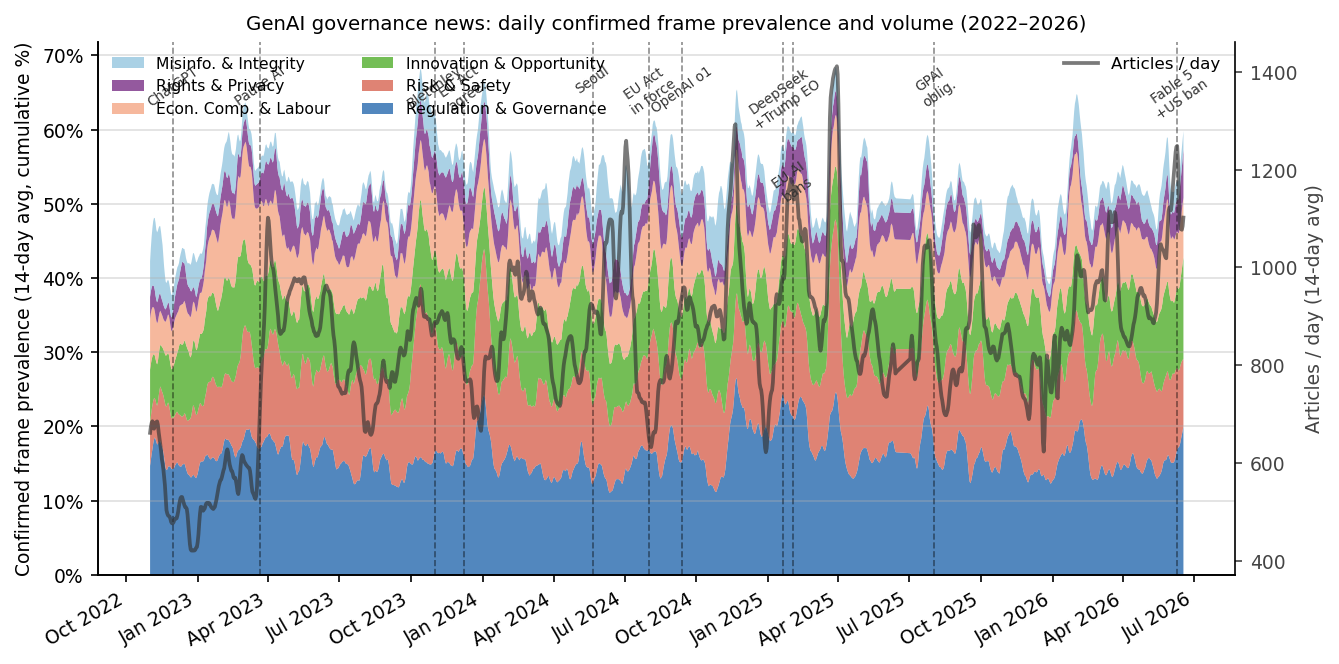

In [9]:
# Stack order: most prevalent frame at bottom for visual stability
FRAME_ORDER = [
    "regulation_governance",
    "risk_safety",
    "innovation_opportunity",
    "economic_competition_labour",
    "rights_privacy",
    "misinformation_integrity",
]

fig, ax = plt.subplots(figsize=(9, 4.5))
dates = vol_smooth.index

# Stacked area — confirmed frame prevalence (14-day avg, cumulative %)
stack_data   = [prev_smooth[f].values * 100 for f in FRAME_ORDER]
stack_colors = [FRAME_COLORS[f] for f in FRAME_ORDER]
stack_labels = [FRAME_LABELS[f] for f in FRAME_ORDER]
ax.stackplot(dates, stack_data, colors=stack_colors, labels=stack_labels, alpha=0.78)

# Milestone markers + labels (staggered y for close pairs via MILESTONE_YLABEL)
for m in MILESTONES:
    mt = pd.Timestamp(m["date"])
    y  = MILESTONE_YLABEL.get(m["name"], 0.96)
    ax.axvline(mt, color="black", lw=0.8, ls="--", alpha=0.45)
    ax.text(mt, y, MILESTONE_SHORT.get(m["name"], m["name"]),
            transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=6.5, rotation=35, color="#333333")

ax.set_ylabel("Confirmed frame prevalence (14-day avg, cumulative %)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))

# Secondary axis — total daily volume (right side)
ax2 = ax.twinx()
ax2.plot(dates, vol_smooth.values, color="#333333", lw=1.8, alpha=0.65,
         label="Articles / day")
ax2.set_ylabel("Articles / day (14-day avg)", color="#444444")
ax2.tick_params(axis="y", colors="#444444")
ax2.spines["right"].set_visible(True)   # rcParams hides right spine globally; re-enable for twinx
ax2.grid(False)

# X-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

# Legends: frames reversed so top-of-stack (Regulation) appears first in list
handles, labels_ = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels_[::-1], frameon=False, fontsize=7.5,
          loc="upper left", ncol=2)
ax2.legend(frameon=False, fontsize=8, loc="upper right")

ax.set_title(
    "GenAI governance news: daily confirmed frame prevalence and volume (2022–2026)",
    fontsize=9.5,
)
plt.tight_layout()
_save(fig, "fig_1_volume_frames")
plt.show()

## Figure 2 — Regional Framing Over Time (Daily Smoothed)

US, EU, and UK daily confirmed frame prevalence for the top 3 frames by volume
(Regulation, Risk, Innovation). Three compact panels sharing the x-axis.

Per-region daily series (`region_smooth`) were computed in the data prep cell above
by grouping `cf_daily` on `(date, region)` and applying the same 14-day centred
rolling mean. Smoother than quarterly and directly comparable to Figure 1.

Saved to `paper/figures/fig_2_regional_framing.{pdf,png}`.

/tmp/ipykernel_19538/835048886.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved fig_2_regional_framing.pdf / .png


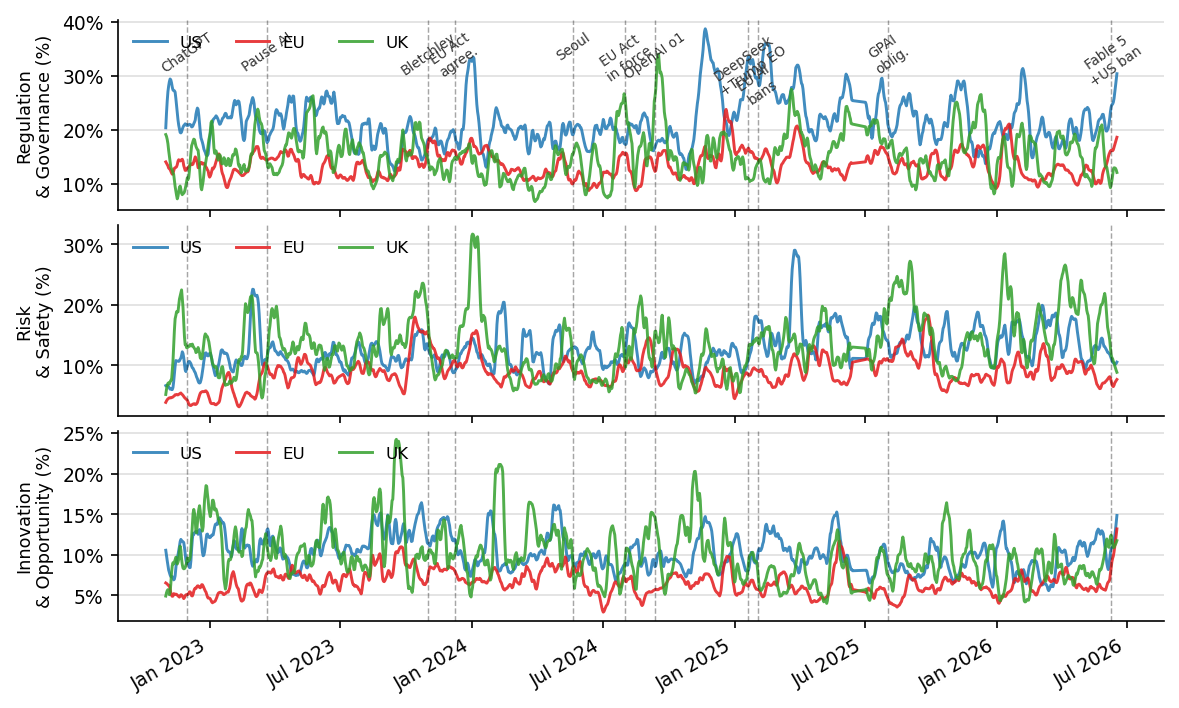

In [10]:
TOP_FRAMES = ["regulation_governance", "risk_safety", "innovation_opportunity"]

fig, axes = plt.subplots(3, 1, figsize=(9, 5.2), sharex=True,
                         gridspec_kw={"hspace": 0.08})

for ax, fname in zip(axes, TOP_FRAMES):
    for region in REGIONS:
        y = region_smooth[region][fname] * 100
        ax.plot(daily_vol.index, y, color=REGION_COLORS[region],
                label=region, lw=1.4, alpha=0.85)

    for m in MILESTONES:
        ax.axvline(pd.Timestamp(m["date"]), color="black", lw=0.7, ls="--", alpha=0.35)

    ax.set_ylabel(FRAME_LABELS[fname].replace(" & ", "\n& ") + " (%)", fontsize=8.5)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.legend(frameon=False, fontsize=8, loc="upper left", ncol=3)

# Milestone labels on top panel only (staggered y for close pairs)
for m in MILESTONES:
    y = MILESTONE_YLABEL.get(m["name"], 0.95)
    axes[0].text(pd.Timestamp(m["date"]), y,
                 MILESTONE_SHORT.get(m["name"], m["name"]),
                 transform=axes[0].get_xaxis_transform(),
                 ha="center", va="top", fontsize=6.5, rotation=35, color="#333333")

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
_save(fig, "fig_2_regional_framing")
plt.show()